In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
LLM_model_tag = 'llama2'
subsample_size = 100
num_datasets = 10
exp_tag = 'safer'
selection_data_file = '../data/selection/harm_sorted_safety_data_with_scores.json'
score_tag = 'harm_score'
top_selection_file = None
bottom_selection_file = f'../../evaluation-artifacts/{LLM_model_tag}/harm-selection-{subsample_size}/harm-selection-{subsample_size}-low/BeaverTails-Evaluation.csv'

### Load scoring data file

In [14]:
selection_data = pd.read_json(selection_data_file)
selection_data = selection_data[['instruction', 'output', 'harm_score']]

### Load subsampled datasets

In [15]:
json_files = [f'../data/training/subsample_{subsample_size}/alpaca_{exp_tag}_{subsample_size}_dataset_{i}.json' for i in range(num_datasets)]
dfs = [pd.read_json(file) for file in json_files]
dfs = [df[df['safety_flag']==True] for df in dfs]

### Validate

In [16]:
for df in dfs:
    if df.shape[0] != subsample_size:
        raise ValueError(f"Unexpected subsample size: {subsample_size} found in dataframe with shape {df.shape}")

### Score subsampled datasets

In [17]:
dfs = [selection_data.merge(df) for df in dfs]
mean_selection_scores = [df[score_tag].mean() for df in dfs]

### Compute safety scores

In [18]:
csv_files = [f'../../evaluation-artifacts/{LLM_model_tag}/alpaca-{exp_tag}-{subsample_size}/alpaca-{exp_tag}-{subsample_size}-dataset{i}/BeaverTails-Evaluation.csv' for i in range(num_datasets)]
result_dfs = [pd.read_csv(file) for file in csv_files]
mean_harmfulness_scores = []
for i, df in enumerate(result_dfs):
    mean_harmfulness_scores.append(df['Harmfulness Score'].mean())

In [ ]:
if bottom_selection_file:
    bottom_selection_result_df = pd.read_csv(bottom_selection_file)
if top_selection_file:
    top_selection_result_df = pd.read_csv(top_selection_file)

### Compute Forecasts

In [20]:
top_score = selection_data[:100][score_tag].mean()
bottom_score = selection_data[-100:][score_tag].mean()

### Visualise results

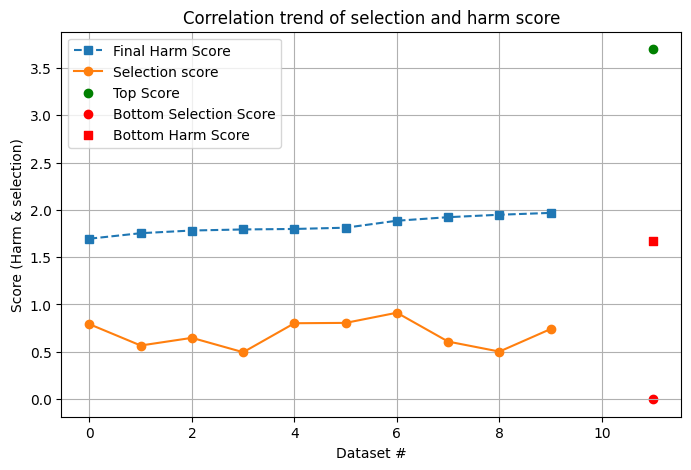

In [ ]:
values1 = mean_selection_scores
values2 = mean_harmfulness_scores
sorted_indices = np.argsort(values2) 
values1 = [values1[i] for i in sorted_indices]  
values2 = [values2[i] for i in sorted_indices]  

x = np.arange(num_datasets)

plt.figure(figsize=(8, 5))
plt.plot(x, values2, marker='s', linestyle='--', label='Final Harm Score')
plt.plot(x, values1, marker='o', linestyle='-', label='Selection score')
if top_selection_file:
    plt.scatter(len(values2)+1, top_score, color='green', marker='o', label='Top Selection Score')
if bottom_selection_file:
    plt.scatter(len(values2)+1, bottom_score, color='red', marker='o', label='Bottom Selection Score')
    plt.scatter(len(values2)+1, bottom_selection_result_df['Harmfulness Score'].mean(), color='red', marker='s', label='Bottom Harm Score')

plt.xlabel("Dataset #")
plt.ylabel("Score (Harm & selection)")
plt.title("Correlation trend of selection and harm score")
plt.legend()

plt.grid(True)
plt.show()

In [23]:
bottom_score

np.float64(-0.0018558030098210455)